# TP N°2 — RNA MLP Backpropagation | Grupo 19
## Dataset: Spotify — Predicción de Popularidad

Este trabaja implementa tres tipos entrenamientos:
- **Modelo 1**: Regresión base con Adam (arquitectura 32-16-8-1)
- **Modelo 2**: Regresión modificada con SGD y momentum (arquitectura 16-8-1)
- **Modelo 3**: Clasificación en 3 categorías *(Baja, Media y Alta)* con softmax (arquitectura 16-8-8-3)

# 0. LIBRERÍAS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
print("Librerías cargadas")

Librerías cargadas


# 1. CARGA Y PREPROCESAMIENTO DE DATOS

In [5]:
# --- Montar Drive y cargar CSV ---
try:
    from google.colab import drive
    drive.mount('/content/gdrive', force_remount=True)
    path = '/content/gdrive/MyDrive/TP IA Grupo 19/TP°2 - RNA/'
    archivo = 'DB_Canciones_Clasicas.csv'   # <-- ajustar nombre real del CSV

    df = pd.read_csv(path + archivo)
    print(f"> CSV cargado: {df.shape[0]} filas, {df.shape[1]} columnas.")
    print(df.head())
    print(df.describe())

except Exception as e:
    print(f"[AVISO] No se pudo cargar el CSV: {e}")
    print("        Se generan datos sintéticos para demostración.")

    num_canciones = 2394
    np.random.seed(42)
    df = pd.DataFrame({
        'danceability':      np.random.rand(num_canciones),
        'energy':            np.random.rand(num_canciones),
        'acousticness':      np.random.rand(num_canciones),
        'liveness':          np.random.rand(num_canciones),
        'valence':           np.random.rand(num_canciones),
        'instrumentalness':  np.random.rand(num_canciones),
        'speechiness':       np.random.rand(num_canciones),
        'loudness':          np.random.uniform(-60, 0, num_canciones),
        'tempo':             np.random.uniform(60, 200, num_canciones),
        'duration_ms':       np.random.randint(100_000, 400_000, num_canciones),
        'time_signature':    np.random.choice([3, 4, 5], num_canciones),
        'explicit':          np.random.choice([0, 1], num_canciones),
        'mode':              np.random.choice([0, 1], num_canciones),
        'key':               np.random.randint(0, 12, num_canciones),
        'popularity':        np.random.randint(0, 101, num_canciones),
    })

# Control: el CSV debe haberse cargado (real o sintético)
assert df is not None, "Error: no se cargaron datos."

# Mostrar info básica
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

print(f"\n> Valores nulos por columna:\n{df.isnull().sum()}")

# Eliminar filas con nulos
df.dropna(inplace=True)
print(f"> Registros tras limpieza: {len(df)}")


# --- Separar features y target ---
columnas_X = [
    'danceability', 'energy', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'speechiness', 'loudness', 'tempo',
    'duration_ms', 'explicit', 'mode', 'key', 'time_signature'
]

X = df[columnas_X].values
y_regresion = df['popularity'].values

print(f"\n> Dimensiones entrada: {X.shape}  ({X.shape[1]} atributos)")
print(f"> Target (popularidad): min={y_regresion.min()}, max={y_regresion.max()}, "
      f"media={y_regresion.mean():.1f}")


# --- Split 70/30 ---
X_train_full, X_test, y_train_full, y_test_reg = train_test_split(
    X, y_regresion, test_size=0.30, random_state=42
)

# --- Escalado (fit solo en entrenamiento, transform en ambos) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)

print(f"\n> Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

Mounted at /content/gdrive
> CSV cargado: 2394 filas, 21 columnas.
   Column1                track_id  \
0    16000  7wrYBASu0OoxoDErd4Edxd   
1    16001  72HdutlIHBZJ7WT1xVAAZT   
2    16002  7JGgKHHDgJCJkQCQxyHHdl   
3    16003  3YRj4jmwois2ctPnhwSwFo   
4    16004  3tp3ij9dtY3CacQgd1OvRf   

                                             artists  \
0                                    Bombay Jayashri   
1  Shankar;Ehsaan;Loy;Alisha Chinai;Shankar Mahad...   
2                           Bombay Jayashri;DJ Aftab   
3                                    Bombay Jayashri   
4                           Bombay Jayashri;Swattrex   

                           album_name              track_name  popularity  \
0           Rehnaa Hai Terre Dil Mein               Zara Zara          58   
1                     Bunty Aur Babli                Kajra Re          59   
2  Hindi Slowed Reverb Bollywood Lofi        Zara Zara - Lofi          54   
3                            Minnalae               Vaseega

# 2. ENTRENAMIENTO 1: Modelo Base (Regresión - Adam)

In [6]:
print("\n--- Iniciando Entrenamiento 1 (Regresión Base — Adam 64-32-16-1) ---")

# EarlyStopping para evitar sobreajuste en modelos largos
es1 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True,
                    min_delta=0.01, start_from_epoch=30, verbose=0)

model_1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16,  activation='relu'),
    Dense(1,  activation='linear')   # salida continua para regresión
], name='Modelo1_Base_Adam')

model_1.compile(optimizer=Adam(learning_rate=0.01),
                loss='mean_squared_error', metrics=['mae'])

history_1 = model_1.fit(
    X_train_scaled, y_train_full,
    validation_split=0.20,
    epochs=200, batch_size=32,
    callbacks=[es1], verbose=0
)
print(f"  Entrenamiento 1 finalizado en época {len(history_1.history['loss'])}.")


--- Iniciando Entrenamiento 1 (Regresión Base — Adam 64-32-16-1) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Entrenamiento 1 finalizado en época 51.


# 3. ENTRENAMIENTO 2: Modelo Modificado (Regresión - SGD)

In [7]:
print("\n--- Iniciando Entrenamiento 2 (Regresión Modificada — SGD 16-8-1) ---")

model_2 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(8,  activation='relu'),
    Dense(1,  activation='linear')
], name='Modelo2_Modificado_SGD')

model_2.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='mean_squared_error', metrics=['mae']
)

history_2 = model_2.fit(
    X_train_scaled, y_train_full,
    validation_split=0.20,
    epochs=200, batch_size=32, verbose=0
)
print(f"  Entrenamiento 2 finalizado en época {len(history_2.history['loss'])}.")


--- Iniciando Entrenamiento 2 (Regresión Modificada — SGD 16-8-1) ---
  Entrenamiento 2 finalizado en época 200.


# 4. ENTRENAMIENTO 3: Clasificación (3 categorías de popularidad)

In [8]:
print("\n--- Iniciando Entrenamiento 3 (Clasificación — 3 Categorías) ---")

def mapear_a_clases(y):
    """Convierte popularidad numérica (0-100) a 3 categorías:
       0 = Baja (0-33), 1 = Media (34-66), 2 = Alta (67-100)"""
    return pd.cut(y, bins=[-1, 33, 66, 101], labels=[0, 1, 2]).astype(int)

y_train_clf = mapear_a_clases(y_train_full)
y_test_clf  = mapear_a_clases(y_test_reg)

# Mostrar distribución de clases (útil para detectar desbalance)
print(f"  Distribución clases train: {dict(zip(*np.unique(y_train_clf, return_counts=True)))}")
print(f"  Distribución clases test:  {dict(zip(*np.unique(y_test_clf,  return_counts=True)))}")

es3 = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True,
                    min_delta=0.001, start_from_epoch=30, verbose=0)

model_3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64,  activation='relu'),
    Dense(16,  activation='relu'),
    Dense(3,  activation='softmax')   # 3 clases
], name='Modelo3_Clasificacion_3Clases')

model_3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train_scaled, y_train_clf,
    validation_split=0.20,
    epochs=200, batch_size=32,
    callbacks=[es3], verbose=0
)
print(f"  Entrenamiento 3 finalizado en época {len(history_3.history['loss'])}.")


--- Iniciando Entrenamiento 3 (Clasificación — 3 Categorías) ---
  Distribución clases train: {np.int64(0): np.int64(893), np.int64(1): np.int64(714), np.int64(2): np.int64(68)}
  Distribución clases test:  {np.int64(0): np.int64(386), np.int64(1): np.int64(303), np.int64(2): np.int64(30)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Entrenamiento 3 finalizado en época 56.


# 5. GRÁFICOS DE EVOLUCIÓN — LOSS

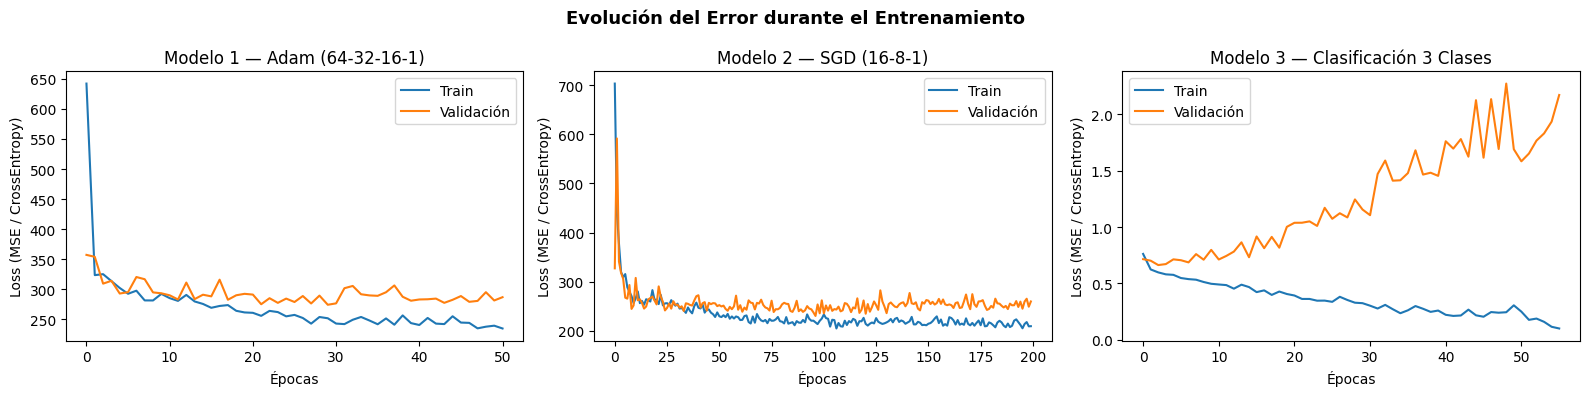

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

configs = [
    (history_1, 'Modelo 1 — Adam (64-32-16-1)', 'Regresión'),
    (history_2, 'Modelo 2 — SGD (16-8-1)',     'Regresión'),
    (history_3, 'Modelo 3 — Clasificación 3 Clases', 'Clasificación'),
]

for ax, (hist, titulo, tipo) in zip(axes, configs):
    ax.plot(hist.history['loss'],     label='Train')
    ax.plot(hist.history['val_loss'], label='Validación')
    ax.set_title(titulo)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss (MSE / CrossEntropy)')
    ax.legend()

plt.suptitle('Evolución del Error durante el Entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. GRÁFICO ADICIONAL — ACCURACY del Modelo 3

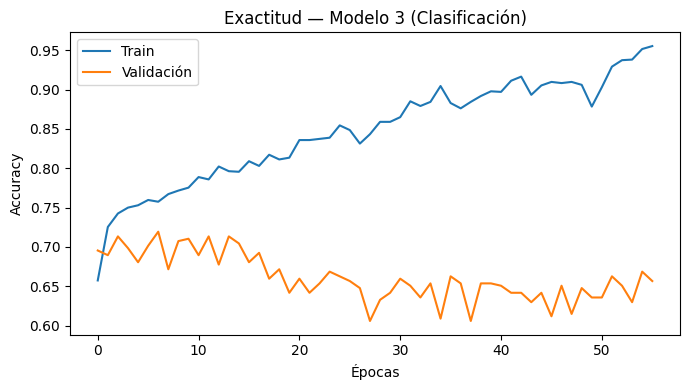

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history_3.history['accuracy'],     label='Train')
plt.plot(history_3.history['val_accuracy'], label='Validación')
plt.title('Exactitud — Modelo 3 (Clasificación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 7. MÉTRICAS DE REGRESIÓN (MAE, Error Relativo, R²)

In [11]:
def calcular_errores_regresion(model, X_data, y_true, nombre):
    preds = model.predict(X_data, verbose=0).flatten()
    mae   = mean_absolute_error(y_true, preds)
    r2    = r2_score(y_true, preds)
    # Error relativo: evita división por cero
    y_safe = np.where(y_true == 0, 1e-5, y_true)
    err_rel = (mae / np.mean(y_safe)) * 100
    print(f"  [{nombre}]")
    print(f"      MAE: {mae:.2f}  |  Error Relativo: {err_rel:.2f}%  |  R²: {r2:.4f}")


print("\n========== MÉTRICAS DE REGRESIÓN — ENTRENAMIENTO ==========")
calcular_errores_regresion(model_1, X_train_scaled, y_train_full,
                           "Modelo 1 Base        (Adam, 32-16-8-1)")
calcular_errores_regresion(model_2, X_train_scaled, y_train_full,
                           "Modelo 2 Modificado  (SGD,  16-8-1)   ")

print("\n========== MÉTRICAS DE REGRESIÓN — PRUEBA ==================")
calcular_errores_regresion(model_1, X_test_scaled, y_test_reg,
                           "Modelo 1 Base        (Adam, 32-16-8-1)")
calcular_errores_regresion(model_2, X_test_scaled, y_test_reg,
                           "Modelo 2 Modificado  (SGD,  16-8-1)   ")


========== MÉTRICAS DE REGRESIÓN — ENTRENAMIENTO ==========
  [Modelo 1 Base        (Adam, 32-16-8-1)]
      MAE: 11.92  |  Error Relativo: 34.27%  |  R²: 0.3872
  [Modelo 2 Modificado  (SGD,  16-8-1)   ]
      MAE: 10.86  |  Error Relativo: 31.24%  |  R²: 0.4458

========== MÉTRICAS DE REGRESIÓN — PRUEBA ==================
  [Modelo 1 Base        (Adam, 32-16-8-1)]
      MAE: 12.27  |  Error Relativo: 35.74%  |  R²: 0.3476
  [Modelo 2 Modificado  (SGD,  16-8-1)   ]
      MAE: 11.64  |  Error Relativo: 33.90%  |  R²: 0.3861


# 8. MÉTRICAS DE CLASIFICACIÓN — MODELO 3


===== CLASIFICACIÓN — ENTRENAMIENTO =====
               precision    recall  f1-score   support

  Baja (0-33)       0.86      0.91      0.88       893
Media (34-66)       0.87      0.81      0.84       714
Alta (67-100)       0.61      0.50      0.55        68

     accuracy                           0.85      1675
    macro avg       0.78      0.74      0.76      1675
 weighted avg       0.85      0.85      0.85      1675



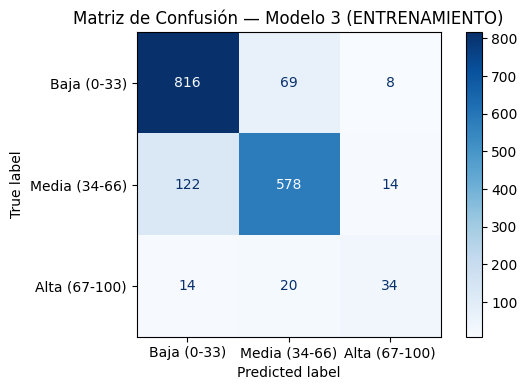


===== CLASIFICACIÓN — PRUEBA =====
               precision    recall  f1-score   support

  Baja (0-33)       0.75      0.82      0.78       386
Media (34-66)       0.69      0.62      0.65       303
Alta (67-100)       0.22      0.17      0.19        30

     accuracy                           0.71       719
    macro avg       0.55      0.53      0.54       719
 weighted avg       0.70      0.71      0.70       719



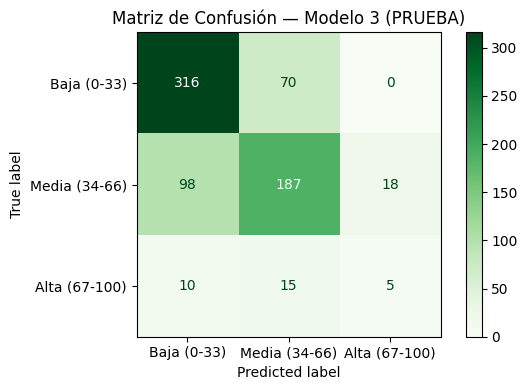

In [12]:
categorias = ["Baja (0-33)", "Media (34-66)", "Alta (67-100)"]

def evaluar_clasificacion(model, X_data, y_true, nombre_set, cmap):
    preds_prob = model.predict(X_data, verbose=0)
    preds_cls  = np.argmax(preds_prob, axis=1)

    print(f"\n===== CLASIFICACIÓN — {nombre_set} =====")
    print(classification_report(y_true, preds_cls, target_names=categorias))

    cm   = confusion_matrix(y_true, preds_cls)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categorias)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(cmap=cmap, ax=ax, values_format='d')
    ax.set_title(f"Matriz de Confusión — Modelo 3 ({nombre_set})")
    plt.tight_layout()
    plt.show()

evaluar_clasificacion(model_3, X_train_scaled, y_train_clf,
                      "ENTRENAMIENTO", plt.cm.Blues)
evaluar_clasificacion(model_3, X_test_scaled,  y_test_clf,
                      "PRUEBA",        plt.cm.Greens)